In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_ta as ta
import optuna
import math
import time
from tqdm import tqdm
from pprint import pprint



In [2]:
def load_candles(base,quote,timeframe):
    data = pd.read_json(f'/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data/binance/{base}_{quote}-{timeframe}.json')
    data.columns = ['timestamp', 'open', 'high', 'low', 'close', 'volume']
    data['timestamp'] = pd.to_datetime(data['timestamp'], unit='ms')
    data.set_index('timestamp', inplace=True)
    return data

best_params= {'ema_fast_len': 40, 'ema_slow_len': 50, 'ema_margin_atr_len': 26, 'ema_margin_atr_mult': 0.10196163809046405}


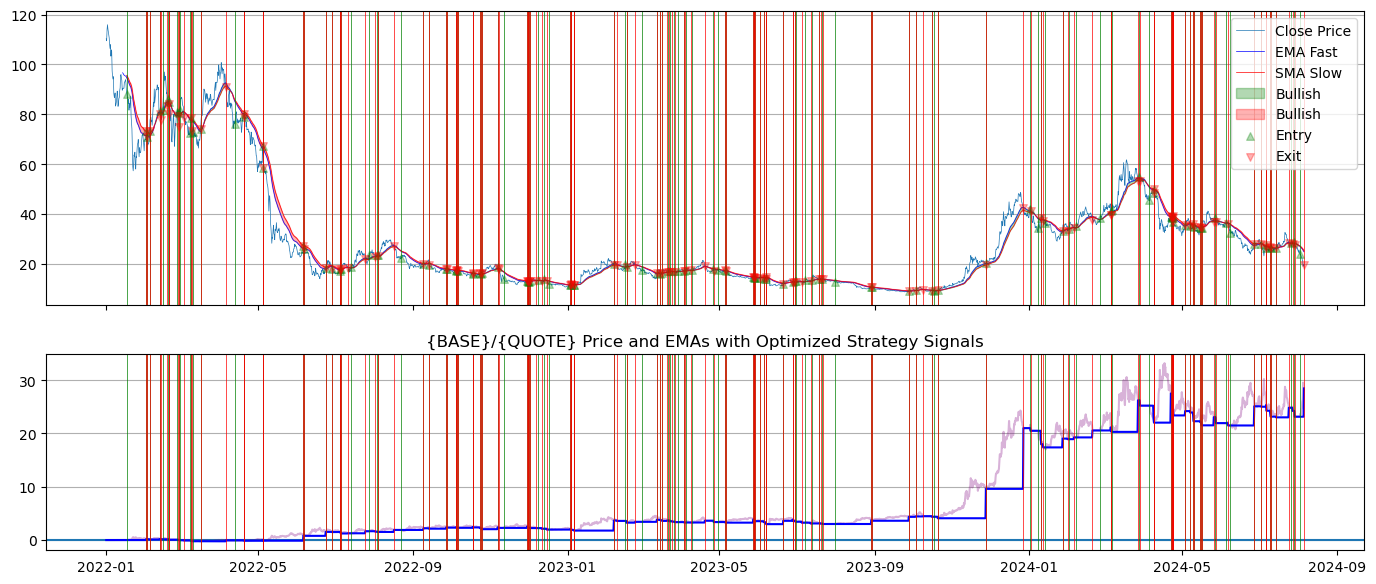

Final Cumulative Return with Optimized Parameters: 3.38
{'annualized_return': 1.7374538333819758,
 'number_of_trades': 286.0,
 'sharpe_ratio': 1.847406213345842,
 'total_return': 28.447080210938925}
Best params: {'ema_fast_len': 40, 'ema_slow_len': 50, 'ema_margin_atr_len': 26, 'ema_margin_atr_mult': 0.10196163809046405}


In [281]:

# Define transaction costs and slippage
transaction_cost = 0.001  # 0.1% transaction cost per trade
slippage = 0.001  # 0.1% slippage per trade



# Define the fitness function
# def calculate_indicators(data, params):
def indicators(data, params):
    ema_fast_len, ema_slow_len, ema_margin_atr_len, ema_margin_atr_mult = [params['ema_fast_len'],
        params['ema_slow_len'], #params['ema_mid_len'],
        params['ema_margin_atr_len'],params['ema_margin_atr_mult']
        ]
        
    data['lclose'] = data['close'].apply(np.log)
    # Ensure that parameters are valid
    ema_fast_len = max(1, int(ema_fast_len))
    ema_slow_len = max(1, int(ema_slow_len))
    # ema_mid_len = max(1, int(ema_mid_len))
    ema_margin_atr_len = max(1, int(ema_margin_atr_len))
    
    # Calculate indicators using pandas_ta
    data['ema_fast'] = ta.ema(data['close'], length=ema_fast_len)
    data['ema_slow'] = ta.ema(data['close'], length=ema_slow_len)
    # data['ema_mid'] = ta.ema(data['close'], length=ema_mid_len)
    data['atr'] = ta.atr(data['high'], data['low'], data['close'], length=ema_margin_atr_len)
    data['ema_diff'] = data['ema_fast'] - data['ema_slow']
    data['ema_slow_lpct'] = np.log(data['close']/data['ema_fast'])
    
    # Generate entry signals 
    data['bull'] = ((data['close'] > data['ema_fast']) \
        # data['ema_diff'] > (ema_margin_atr_mult * data['atr'])) & \
        # ((data['close'] > data['ema_slow']) \
        # & (data['ema_slow_lpct'] < 0.3* atr_filter_mult * data['atr']) \
    )        
    data['bull_exit'] =  ((data['close'] < data['ema_fast']) \
        
        # | (data['ema_slow_lpct'] > atr_filter_mult * data['atr']) \
    )
        
    
    data['bear'] = (
        (data['ema_diff']) < -(ema_margin_atr_mult * data['atr'])) \
        & ((data['close'] < data['ema_fast'])
    )
    data['bear_exit'] =  (data['close'] > data['ema_fast'])
    
    return data
    
    # Generate exit signals
    # data['exit'] = (data['close'] > data['ema_slow']) & (data['close'] < data['ema_fast'])
      
def backtest(data, short_long=None, pos_mult=1):
    if short_long is None: short_long = [1,-1]

    # Initialize the 'position' column
    data['position'] = 0
    
    # # Set the 'position' column based on the signals
    # if 1 in short_long:
    #     data.loc[data['bull'], 'position'] = 1        
    #     data.loc[(data['bull'] & data['bull_exit']), 'position'] = 0   
    # # Exit position when exit signal is True
    
    # Set the 'position' column based on the signals
    # if -1 in short_long:
    #     data.loc[(data['bear']), 'position'] = -1    
    #     data.loc[(data['bear'] & data['bear_exit']), 'position'] = 0
    ###    
    data['position'] = pos_mult*(int(1 in short_long) * (data['bull'] &~ data['bull_exit'])) - (int(-1 in short_long) * (data['bear'] &~ data['bear_exit']))
    positions_shifted = data['position'].shift()#.fillna(0).astype(int)
    data['trade'] = data['position'].diff()#.fillna(0).astype(int)
    data.at[data.index[-1],'trade'] = -data.iloc[-1]['position']
    data['strategy_returns'] = positions_shifted * (data['lclose'].diff().fillna(0))
    number_of_trades = data['trade'].abs().sum()
    data['strategy_returns'] -= data['trade'].abs() * (transaction_cost + slippage)
    data['cumulative_returns'] = data['strategy_returns'].cumsum()
    ###
    
    data['pct_strategy_returns'] = np.exp(data['strategy_returns']) - 1
    data['pct_cumulative_returns'] = np.exp(data['cumulative_returns']) - 1
    ###
    
    # Calculate performance metrics
    total_return = data['pct_cumulative_returns'].iloc[-1]
    annualized_return = data['pct_strategy_returns'].mean() * 365 * 24 / 8  # Assuming 8-hour bars
    annualized_volatility = data['pct_strategy_returns'].std() * np.sqrt(365 * 24 / 8)
    sharpe_ratio = annualized_return / annualized_volatility
    

    # Calculate trade returns
    # data['trade_returns'] = data['strategy_returns'] * data['trade'].shift(-1)

    # Calculate winning trades and losing trades
    # winning_trades = data['trade_returns'][data['trade_returns'] > 0]
    # losing_trades = data['trade_returns'][data['trade_returns'] <= 0]

    # Calculate win ratio
    # if number_of_trades > 0:
    #     win_ratio = len(winning_trades) / number_of_trades
    # else:
    #     win_ratio = np.nan

    # Calculate average win and average loss
    # average_win = winning_trades.mean() if len(winning_trades) > 0 else np.nan
    # average_loss = losing_trades.mean() if len(losing_trades) > 0 else np.nan

    
    return {'sharpe_ratio': sharpe_ratio, 'total_return': total_return, 'annualized_return':annualized_return,
            'number_of_trades':number_of_trades,
            # 'win_ratio':win_ratio,'average_win':average_win,'average_loss':average_loss
            }

def decorate_trades(data):
    positions_shifted = data['position'].shift().fillna(0).astype(int)
    data['entry_point'] = ((data['position'] != 0) & (data['position'] == np.sign(data['trade']))).astype(int)
    data['exit_point'] = ((positions_shifted != 0) & (positions_shifted == np.sign(-data['trade']))).astype(int)

    data['cum_trade_returns'] = data['cumulative_returns'] * data['exit_point']
    # data.loc[(data['trade'] == 0), 'cum_trade_returns'] = 0
    data['cum_trade_returns'].replace(0, pd.NA, inplace=True)
    data['cum_trade_returns'] = data['cum_trade_returns'].fillna(method='ffill').fillna(0)#.diff().fillna(0)
    data['pct_cum_trade_returns'] = np.exp(data['cum_trade_returns']) -1
    return data
 

def optimize(data, short_long=None, pos_mult=1):
    # if short_long is None: short_long = [1,-1]
    # Define the objective function for Optuna
    def objective(trial):
        global data
        ema_fast_len = trial.suggest_int('ema_fast_len', 4, 50)
        ema_slow_len = trial.suggest_int('ema_slow_len', 20, 100)
        # ema_mid_len = trial.suggest_int('ema_mid_len', 20, 100)
        ema_margin_atr_len = trial.suggest_int('ema_margin_atr_len', 7, 50)
        ema_margin_atr_mult = trial.suggest_uniform('ema_margin_atr_mult', 0.1, 5)
        # atr_filter_mult = trial.suggest_uniform('atr_filter_mult', 0.05, 2)
        # resample_len = trial.suggest_int('resample_len', 1, 40)
        
        # params = (ema_fast_len, ema_slow_len, ema_margin_atr_len, ema_margin_atr_mult)
        params = {'ema_fast_len':ema_fast_len, 'ema_slow_len':ema_slow_len, #'ema_mid_len':ema_mid_len, 
                  'ema_margin_atr_len':ema_margin_atr_len, 
                  'ema_margin_atr_mult':ema_margin_atr_mult, 
                #   'atr_filter_mult': atr_filter_mult
                  }
        data = indicators(data,params)
        # sharpe_ratio,total_return,annualized_return,number_of_trades,win_ratio,average_win,average_loss = backtest(data)
        results = backtest(data,short_long,pos_mult=pos_mult)
        
        return results['sharpe_ratio'] #/ math.cos(number_of_trades)

    # Run the optimization
    study = optuna.create_study(direction='maximize')
    optuna.logging.set_verbosity(optuna.logging.ERROR)
    study.optimize(objective, n_trials=100)

    # Get the best parameters
    # best_params = study.best_params
    # print(f"Best Parameters: {best_params}")
    return study

def print_performance(data, params, window=None, short_long=None):
    # Set default window to the entire DataFrame if not provided
    if window is None:
        window = data.index
    
    
    # ema_fast_len, ema_slow_len, ema_margin_atr_len, ema_margin_atr_mult
    # data = indicators(data,[params['ema_fast_len'],params['ema_slow_len'],
    #     params['ema_margin_atr_len'],params['ema_margin_atr_mult']])
    data = indicators(data,params)
    # sharpe_ratio,total_return,annualized_return,number_of_trades,win_ratio,average_win,average_loss = backtest(
    #     data)
    results = backtest(data, short_long)
    decorate_trades(data)

    data = data.loc[window].copy()

    # Identify trade entries and exits
    # entry_points = data.index[(data['trade'] == 1) & (data['position'] != 0)]
    # exit_points = data.index[(data['trade'] == 1) & (data['position'] == 0)]
    entry_points = data.index[(data['entry_point'] == 1)]
    exit_points = data.index[(data['exit_point'] == 1)]

    # Ensure entry and exit points are aligned
    # if len(exit_points) < len(entry_points):
    #     entry_points = entry_points[:-1]

    # Vectorized calculation of PnL
    entry_prices = data.loc[entry_points, 'close'].values
    exit_prices = data.loc[exit_points, 'close'].values
    # trade_pnl = (exit_prices - entry_prices) / entry_prices  # Calculate percentage return
    # cumulative_trade_pnl = (1 + pd.Series(trade_pnl, index=exit_points)).cumprod()

    # Plot the results with the best parameters
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(17, 7), sharex=True, height_ratios=[1.5,1])
    # plt.figure(figsize=(14, 3))
    ax1.plot(data.index, data['close'], label='Close Price',lw=0.5)
    ax1.plot(data.index, data['ema_fast'], label='EMA Fast', color='blue',lw=0.5)
    ax1.plot(data.index, data['ema_slow'], label='SMA Slow', color='red',lw=0.5)
    # ax1.plot(data.index, data['ema_mid'], label='SMA Slow', color='gray',lw=1.5)
    ax1.fill_between(data.index, data['ema_fast'], data['ema_slow'], where=(data['ema_diff'] > 0), color='green', alpha=0.3, label='Bullish')
    ax1.fill_between(data.index, data['ema_fast'], data['ema_slow'], where=(data['ema_diff'] < 0), color='red', alpha=0.3, label='Bullish')
    ax1.scatter(entry_points, data.loc[entry_points, 'close'], marker='^', color='g', s=30, label='Entry', zorder=5,alpha=0.3)
    ax1.scatter(exit_points, data.loc[exit_points, 'close'], marker='v', color='r', s=30, label='Exit', zorder=5,alpha=0.3)
 
    ax1.legend(loc='best')
    plt.title('{BASE}/{QUOTE} Price and EMAs with Optimized Strategy Signals')


    # ax2 = plt.twinx()
    # ax2.set_yscale('log')
    ax2.axhline(0)
    ax2.plot(data['pct_cumulative_returns'], label='Cumulative Returns', color='purple', alpha=0.3)
    ax2.plot(data['pct_cum_trade_returns'], label='Cumulative Returns', color='blue')
    # ax2.plot(data.index, data['cumulative_returns'], label='Cumulative Returns', color='purple')
    # ax2.plot(np.append([data.index.values[0]], exit_points.values), np.append([1], cumulative_trade_pnl), label='Cumulative Returns', color='purple')
    # ax2.plot((1+data['trade_returns']).cumprod(), label='Cumulative Returns', color='purple')

    for x in entry_points: ax1.axvline(x, lw=0.5, c='green');ax2.axvline(x, lw=0.5, c='green')
    for x in exit_points: ax1.axvline(x, lw=0.5, c='red');ax2.axvline(x, lw=0.5, c='red')
    ax1.grid(axis='y')
    ax2.grid(axis='y')
    
    plt.show()

# Plot cumulative returns with the best parameters
# plt.figure(figsize=(14, 3))
# plt.plot(data.index, data['cumulative_returns'], label='Cumulative Returns', color='purple')
# plt.legend(loc='best')
# plt.title('Cumulative Returns of the Optimized Strategy')
# plt.show()

    # Print final cumulative return with the best parameters
    print(f"Final Cumulative Return with Optimized Parameters: {data['cumulative_returns'].iloc[-1]:.2f}")

    # Print performance metrics
    pprint(results)
    # print(f"Sharpe Ratio: {results['sharpe_ratio']:.2f}")
    # print(f"Total Return: {results['total_return']:.2f}")
    # print(f"Annualized Return: {results['annualized_return']:.2f}")
    # print(f"Number of Trades: {results['number_of_trades']:.0f}")
    # print(f"Win Ratio: {results['win_ratio']:.2f}")
    # print(f"Average Win: {results['average_win']:.4f}")
    # print(f"Average Loss: {results['average_loss']:.4f}")


# Load the data

# Load the data
data = load_candles('AVAX','USDT','1h')['2022':'2025']
ohlc_dict = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}

data = data.resample(str(8) + 'H').agg(ohlc_dict)

# data = data['2021-11-01':].copy()
short_long = [-1,1]
study = optimize(data, short_long=short_long, pos_mult=1)
best_params = study.best_params
# best_params = {'ema_fast_len': 8, 'ema_slow_len': 100, 'ema_margin_atr_len': 45, 'ema_margin_atr_mult': 2.3369417327913116}

print(f'best_params= {best_params}')
# window = data['2024-01':'2025-01'].index
window = None
print_performance(data,best_params,window=window,short_long=short_long)
print(f'Best params: {best_params}')

best_params= {'ema_fast_len': 29, 'ema_slow_len': 66, 'ema_margin_atr_len': 15, 'ema_margin_atr_mult': 4.991272842886802}


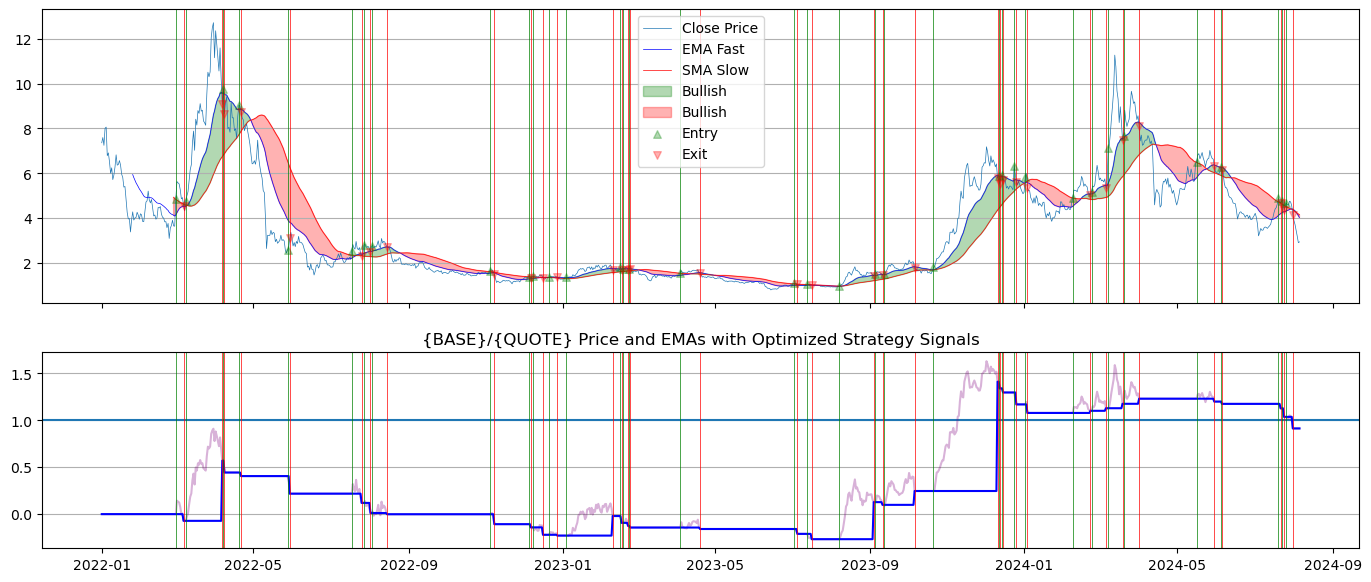

Final Cumulative Return with Optimized Parameters: 0.91
{'annualized_return': 0.9233133818568512,
 'number_of_trades': 72.0,
 'sharpe_ratio': 0.8285154594220648,
 'total_return': -0.08680512095801829}
Best params: {'ema_fast_len': 29, 'ema_slow_len': 66, 'ema_margin_atr_len': 15, 'ema_margin_atr_mult': 4.991272842886802}


In [177]:

# Load the data
data = load_candles('RUNE','USDT','1h')['2022':'2025']
ohlc_dict = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}

data = data.resample(str(21) + 'H').agg(ohlc_dict)

# data = data['2021-11-01':].copy()
short_long = [-1,1]
# study = optimize(data, short_long=short_long)
# best_params = study.best_params
# best_params = {'ema_fast_len': 8, 'ema_slow_len': 100, 'ema_margin_atr_len': 45, 'ema_margin_atr_mult': 2.3369417327913116}

print(f'best_params= {best_params}')
# window = data['2024-01':'2025-01'].index
window = None
print_performance(data,best_params,window=window,short_long=short_long)
print(f'Best params: {best_params}')

In [11]:
close = np.random.uniform(2000, 3000, len(bull)).astype(int)

In [266]:
data = load_candles('AVAX','USDT','1h')#['2021-04':]
ohlc_dict = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}
test_results = []
short_long=[-1,1]
resample_periods = np.arange(5,100,1)
for i in tqdm(resample_periods, desc="Processing"):
    rdata = data.resample(f'{i}H').agg(ohlc_dict)
    study = optimize(rdata, short_long=short_long)
    test_results.append(study)


Processing: 100%|██████████| 95/95 [04:28<00:00,  2.82s/it]


In [269]:
# data = load_candles('PEPE','USDT','2h')#['2021-04':]
rparams = [study.best_params for study in test_results]
rbacktests = []
short_long=[-1,1]
for i in tqdm(range(len(resample_periods))):
    rdata = data.iloc[5:].resample(f'{resample_periods[i]}H').agg(ohlc_dict)
    params = test_results[i].best_params
    rdata = indicators(rdata, params)
    test_result = backtest(rdata, short_long)
    decorate_trades(rdata)
    rbacktests.append(test_result)
    

             
# [(resample_periods[i],rbacktests[i][1]) for i in range(len(rbacktests))]

100%|██████████| 95/95 [00:01<00:00, 68.63it/s]


In [270]:

suffixes = ['_suffix', '_suffix2']

# Function to remove suffixes from a key
def remove_suffixes(key, suffixes):
    for suffix in suffixes:
        if key.endswith(suffix):
            return key[:-len(suffix)]
    return key

# Function to remove the suffixes from dictionary keys
def remove_suffixes_from_dict(d, suffixes):
    return {remove_suffixes(key, suffixes): value for key, value in d.items()}

dfres = pd.DataFrame([{'period': i, 'days':int(i*2/24),  **(remove_suffixes_from_dict(d1.best_params, ['_len'])), **d2} for i, d1, d2 in zip(resample_periods,test_results, rbacktests)])

dfres.head(10)

dfres.sort_values(by='total_return', axis=0, ascending=False).head(10)

,period,days,ema_fast,ema_slow,ema_mid,ema_margin_atr,ema_margin_atr_mult,sharpe_ratio,total_return,annualized_return,number_of_trades
22,27,2,44,95,94,12,0.827123,3.022425,158.172157,6.635441,54.0
18,23,1,32,92,94,19,1.153796,2.776422,128.708358,5.392993,74.0
23,28,2,10,95,93,19,1.487970,3.056356,128.267324,6.616763,56.0
9,14,1,17,93,97,13,1.403264,2.141145,116.961677,3.302495,122.0
15,20,1,36,100,90,22,0.972625,2.590060,115.750344,4.576492,94.0
6,11,0,31,92,95,25,1.082004,1.903296,114.221782,2.557411,178.0
3,8,0,31,98,93,24,1.218936,1.648244,112.295512,1.811628,246.0
0,5,0,33,94,94,17,1.055231,1.286989,108.320169,1.150343,396.0
20,25,2,11,94,94,22,1.460497,2.784492,108.220428,5.849570,70.0
21,26,2,42,100,91,43,0.932648,2.759540,96.736244,5.973732,56.0


In [ ]:

dfres.sort_values(by='total_return', axis=0, ascending=False).head(50)

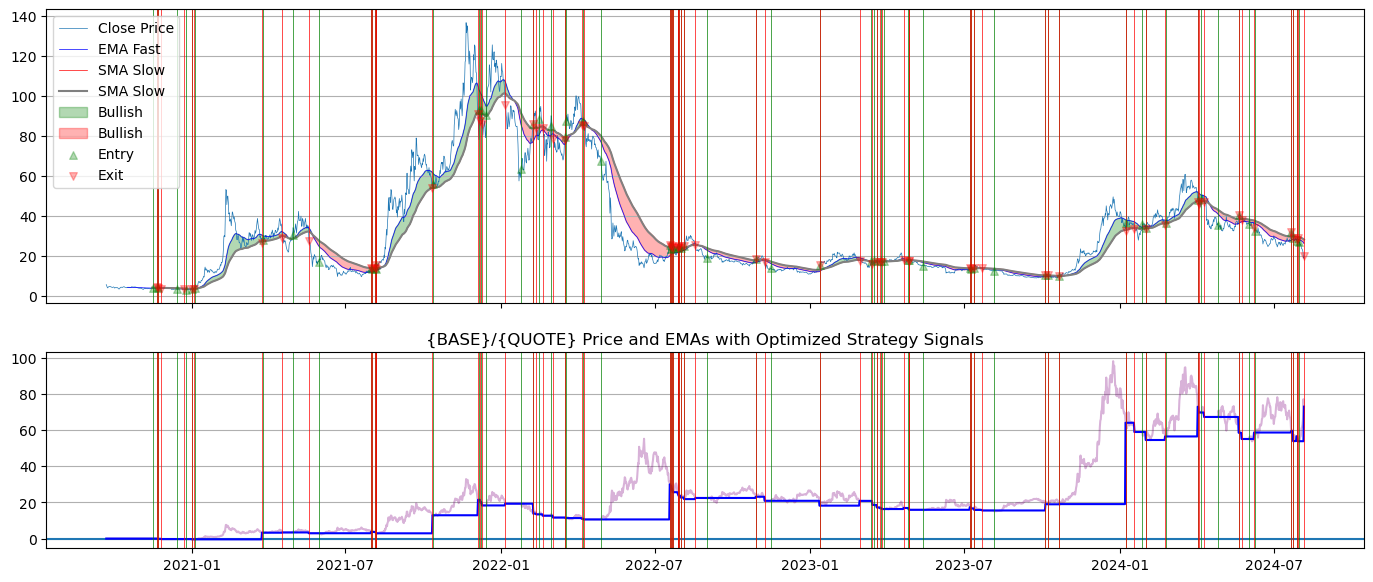

Final Cumulative Return with Optimized Parameters: 4.30
{'annualized_return': 3.0789301060730088,
 'number_of_trades': 138.0,
 'sharpe_ratio': 2.0079809909623916,
 'total_return': 72.91674828324204}
{'ema_fast_len': 34, 'ema_slow_len': 96, 'ema_mid_len': 95, 'ema_margin_atr_len': 31, 'ema_margin_atr_mult': 1.0732719271428541}


In [274]:
# i = 81
data = load_candles('AVAX','USDT','1h')#['2021-04':]
i=22
rdata = data.resample(f'{resample_periods[9]}H').agg(ohlc_dict)#['2021-04':]
# study = test_results[i]
study = optimize(rdata)
params = study.best_params
short_long = [-1,1]
window = None
window = data['2023-06':'2025-01'].index
print_performance(rdata, test_results[i].best_params, short_long=short_long)

print(params)

In [323]:

data = load_candles('ETC','USDT','1d')#['2021-04':]
data.join(data.resample(f'{12}H').agg(ohlc_dict),rsuffix="_res")

,open,high,low,close,volume,open_res,high_res,low_res,close_res,volume_res
timestamp,,,,,,,,,,
2020-01-01,4.4945,4.5742,4.4723,4.5035,526602.35,4.4945,4.5742,4.4723,4.5035,526602.35
2020-01-02,4.5070,4.5123,4.1680,4.2283,1838183.26,4.5070,4.5123,4.1680,4.2283,1838183.26
2020-01-03,4.2329,4.6299,4.1791,4.5768,2720581.72,4.2329,4.6299,4.1791,4.5768,2720581.72
2020-01-04,4.5769,4.7842,4.5207,4.7598,1679464.53,4.5769,4.7842,4.5207,4.7598,1679464.53
2020-01-05,4.7587,5.0052,4.7325,4.8784,2448806.94,4.7587,5.0052,4.7325,4.8784,2448806.94
...,...,...,...,...,...,...,...,...,...,...
2024-07-30,22.8300,23.0600,21.9700,22.2400,234138.47,22.8300,23.0600,21.9700,22.2400,234138.47
2024-07-31,22.2400,22.5700,21.6500,21.7800,229398.50,22.2400,22.5700,21.6500,21.7800,229398.50
2024-08-01,21.7800,22.1800,20.4200,21.5400,504689.93,21.7800,22.1800,20.4200,21.5400,504689.93
